In [2]:
#STEP 1: Import Required Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)


In [3]:
#step 2 : loading dataset
train = pd.read_csv(r"C:\Users\GANAPATI\Downloads\archive (2)\fraudTrain.csv")
test  = pd.read_csv(r"C:\Users\GANAPATI\Downloads\archive (2)\fraudTest.csv")
train.head()







,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
# STEP 3: Hard Limit Dataset Size (FAST)

train = train.sample(
    n=100000,       
    random_state=42
)

test = test.sample(
    n=40000,        
    random_state=42
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (100000, 23)
Test shape: (40000, 23)


In [5]:
cols_to_remove = [
    'Unnamed: 0', 'first', 'last', 'street',
    'trans_num', 'merchant', 'cc_num',
    'dob', 'trans_date_trans_time'
]

train.drop(columns=cols_to_remove, inplace=True, errors='ignore')
test.drop(columns=cols_to_remove, inplace=True, errors='ignore')



In [6]:
target = 'is_fraud'

X_train = train.drop(columns=target)
y_train = train[target]

X_test  = test.drop(columns=target)
y_test  = test[target]


In [7]:
from sklearn.preprocessing import OrdinalEncoder

cat_cols = X_train.select_dtypes(include='object').columns

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols]  = encoder.transform(X_test[cat_cols])


In [8]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=800,
    class_weight='balanced',
    solver='saga',
    n_jobs=-1
)

log_model.fit(X_train, y_train)

print("Logistic Accuracy:",
      log_model.score(X_test, y_test))


Logistic Accuracy: 0.053375


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=40,
    max_depth=14,
    min_samples_split=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      rf_model.score(X_test, y_test))


Random Forest Accuracy: 0.99525


In [10]:
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)
print("Confusion Matrix:\n", cm)



Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39846
           1       0.43      0.67      0.52       154

    accuracy                           1.00     40000
   macro avg       0.71      0.83      0.76     40000
weighted avg       1.00      1.00      1.00     40000

Confusion Matrix:
 [[39707   139]
 [   51   103]]


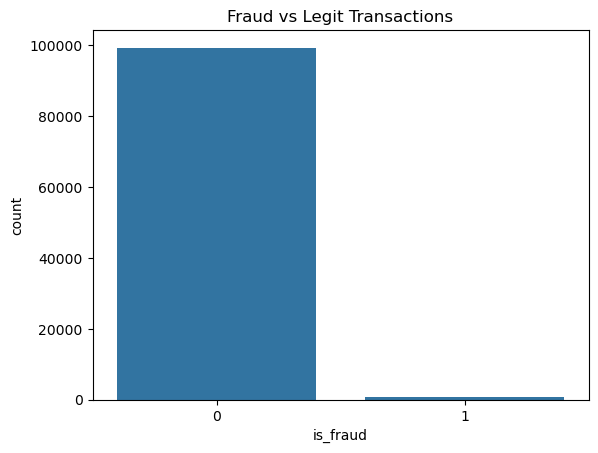

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_train)
plt.title("Fraud vs Legit Transactions")
plt.show()
